# Análise Exploratória dos Dados de Segurança do ISP

## Estatísticas e Previsão de Segurança: Roubos e Furtos em coletivo no Rio de Janeiro

O presente estudo originou-se de um processo exploratório de diferentes bases de dados do Instituto de Segurança Pública (ISP). Inicialmente, foram avaliados dados sobre letalidade violenta e feminicídios. No entanto, ambas as bases mostraram-se insuficientes para uma análise estatística aprofundada: a primeira por apresentar baixa densidade amostral e a segunda pelo volume reduzido de registros para o desenvolvimento de um modelo. Dessa forma, optou-se pela utilização do dataset "Estatísticas de segurança: série histórica mensal por área de delegacia", que oferece dados geolocalizados desde 2003. O foco do estudo foi delimitado para a segurança no transporte público, especificamente o recorte de crimes ocorridos em coletivos na Capital do Estado e Baixada Fluminense.

Nesse notebook faremos uma análise exploratória inicial do nosso dataset. Temos como objetivo final prever a criminalidade em ônibus em cada região com base na série temporal. Vamos, inicialmente, avaliar o conteúdo do dataset, verificar quais colunas podem ser úteis e fazer uma análise geral delas.

## Configurações iniciais do projeto

Carregando as bibliotecas e definindo a paleta de cores:

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from faz_mapa import faz_mapa
from IPython.display import IFrame

In [127]:
sequentialpalette = sns.color_palette('inferno')
qualitativepalette = sns.color_palette('colorblind', n_colors=20)

sns.set_palette(palette=sequentialpalette)

sns.set_style("whitegrid")

In [ ]:
try:
    with open("../datasets/dataframe.pkl","rb") as file:
        df = pickle.load(file)
except:
    df = pd.read_csv("../datasets/BaseDPEvolucaoMensalCisp.csv", sep=";", decimal=",", encoding="latin1")

## Forma e Tratamento dos Dados
Vamos dar uma primeira olhada em como os dados são estruturados no dataset e entender um pouco mais sobre os seus valores

In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37588 entries, 0 to 37587
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        37588 non-null  int64  
 1   mes                         37588 non-null  int64  
 2   ano                         37588 non-null  int64  
 3   mes_ano                     37588 non-null  str    
 4   aisp                        37588 non-null  int64  
 5   risp                        37588 non-null  int64  
 6   munic                       37588 non-null  str    
 7   mcirc                       37588 non-null  int64  
 8   regiao                      37588 non-null  str    
 9   hom_doloso                  37588 non-null  int64  
 10  lesao_corp_morte            37588 non-null  int64  
 11  latrocinio                  37588 non-null  int64  
 12  cvli                        37588 non-null  int64  
 13  hom_por_interv_policial     37588 non-null

As colunas "`roubo_em_coletivo`" e "`furto_coletivo`", que dizem respeito a segurança no transporte público, foram selecionadas para a análise. Além disso, temos os campos "`cisp`", "`aisp`" e "`risp`", que servem de proxy com diferentes níveis de granularidade para as regiões às quais os incidentes foram reportados,  sendo CISP o georreferenciamento mais granular disponível na base de dados. Como as CISPs foram as unidades mais análisadas, trazemos sua definição aqui.

    "As Circunscrições Integradas de Segurança Pública - CISP, correspondem às áreas territoriais de atuação e responsabilidade conjunta das delegacias distritais da Secretaria de Estado de Polícia Civil (SEPOL) e das companhias integradas da Secretaria de Estado de Polícia Militar (SEPM). As CISP têm como princípio básico o conceito de que a responsabilidade pelo policiamento de uma subárea da companhia de Polícia Militar deverá coincidir com a circunscrição de uma delegacia de Polícia Civil. Nesse sentido, as CISP constituem a esfera de integração territorial, em nível operacional, das Companhias Integradas da SEPM com as Delegacias de Polícia da SEPOL. As CISP caracterizam, segundo este modelo de integração geográfica, a menor instância de apuração dos indicadores de criminalidade." 

Pode-se ver mais a respeito sobre essas regiões e o significado de outras colunas do dataset [nesse documento](https://www.ispdados.rj.gov.br/Arquivos/Relacaodas%20RISP_AISP.pdf). 

Observa-se que o dataset possui muitas colunas. A maioria parece não muito relacionada ao nosso problema. Porém, primeiramente, vamos verificar e corrigir os nulos para, depois, selecionar as colunas que queremos.

In [130]:
df.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 65, dtype: int64

Vamos analisar quais regiões temos para selecionar

In [131]:
print(df["regiao"].unique())

<StringArray>
[                      'Capital',            'Baixada Fluminense',
                      'Interior', 'Grande NiterÃÂÃÂÃÂÃÂ³i',
                'Grande Niterói']
Length: 5, dtype: str


Para limitar o escopo, vamos selecionar somente a capital

In [132]:
df = df[ df["regiao"].isin(["Capital"])]
df.info()

<class 'pandas.DataFrame'>
Index: 11279 entries, 0 to 37491
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        11279 non-null  int64  
 1   mes                         11279 non-null  int64  
 2   ano                         11279 non-null  int64  
 3   mes_ano                     11279 non-null  str    
 4   aisp                        11279 non-null  int64  
 5   risp                        11279 non-null  int64  
 6   munic                       11279 non-null  str    
 7   mcirc                       11279 non-null  int64  
 8   regiao                      11279 non-null  str    
 9   hom_doloso                  11279 non-null  int64  
 10  lesao_corp_morte            11279 non-null  int64  
 11  latrocinio                  11279 non-null  int64  
 12  cvli                        11279 non-null  int64  
 13  hom_por_interv_policial     11279 non-null  int

Vamos ver quais risps nos sobram

In [133]:
df["risp"].value_counts()

risp
1    6905
2    4371
6       3
Name: count, dtype: int64

Vemos que a RISP 6 quase não tem dados. Vamos olhar isso um pouco mais a fundo.

In [134]:
df[ df["risp"]==6]

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
11,16,1,2003,2003m01,36,6,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,141,3,1,0,0,0,973,3
137,16,2,2003,2003m02,36,6,Rio de Janeiro,3304557,Capital,5,...,NaN,NaN,122,8,2,0,0,0,1015,3
263,16,3,2003,2003m03,36,6,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,132,5,4,0,0,0,1079,3


Observando os dicionários e mapas da base, vemos que esses dados estão com a risp sendo 6, porem a regiao capital e cisp 16 se referem a barra da tijuca, pertencente a risp 2. Como sao poucos dados, assumimos que se trata de um erro de preenchimento, e trocaamos para o valor correto

In [135]:
df.loc[:,"risp"] = df.loc[:,"risp"].replace(6,2)
df["risp"].value_counts()

risp
1    6905
2    4374
Name: count, dtype: int64

Vamos observar como ficou o resultado!

In [136]:
df.info()

<class 'pandas.DataFrame'>
Index: 11279 entries, 0 to 37491
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        11279 non-null  int64  
 1   mes                         11279 non-null  int64  
 2   ano                         11279 non-null  int64  
 3   mes_ano                     11279 non-null  str    
 4   aisp                        11279 non-null  int64  
 5   risp                        11279 non-null  int64  
 6   munic                       11279 non-null  str    
 7   mcirc                       11279 non-null  int64  
 8   regiao                      11279 non-null  str    
 9   hom_doloso                  11279 non-null  int64  
 10  lesao_corp_morte            11279 non-null  int64  
 11  latrocinio                  11279 non-null  int64  
 12  cvli                        11279 non-null  int64  
 13  hom_por_interv_policial     11279 non-null  int

Olhando um pouco mais minuciosamente as colunas, vimos que diversas CISPs não tem dados antes de 2014

In [137]:
df.groupby("cisp")["ano"].min()

cisp
1     2003
4     2003
5     2003
6     2003
7     2003
9     2003
10    2003
11    2013
12    2003
13    2003
14    2003
15    2003
16    2003
17    2003
18    2003
19    2003
20    2003
21    2003
22    2003
23    2003
24    2003
25    2003
26    2003
27    2003
28    2003
29    2003
30    2003
31    2003
32    2003
33    2003
34    2003
35    2003
36    2003
37    2003
38    2003
39    2003
40    2003
41    2003
42    2010
43    2003
44    2003
45    2013
Name: ano, dtype: int64

Portanto, escolhemos usar apenas os dados de 2014 pra frente.

In [138]:
df = df[df["ano"] >= 2014]

Por fim, salvamos em um arquivo pickle para facilitar o acesso.

In [139]:
df.to_pickle('../datasets/dataframe.pkl')

Percebendo que não temos dados nulos, verificamos o histórico da base:

In [140]:
print(f"Min: {df['mes_ano'].min()}, Max: {df['mes_ano'].max()}")

Min: 2014m01, Max: 2026m03


Temos dados desde Janeiro de 2014 até Março de 2026.

Vamos então ver a quantidade de resgistros no dataset:

In [141]:
print("Número de registros:", len(df))

Número de registros: 6087


## Exploração de furtos e roubos em coletivos

Vamos analisar incialmente as principais variáveis de interesse do estudo: `roubo_em_coletivo` e `furto_coletivo` por CISP, RISP ou AISP.

In [142]:
df["crime_coletivo"] = df["roubo_em_coletivo"] + df["furto_coletivo"]
df_coletivo = df[["crime_coletivo","furto_coletivo","roubo_em_coletivo", "cisp"]]

In [143]:
print(df_coletivo.groupby("cisp"))

In [144]:
df_map = df_coletivo.groupby("cisp")["crime_coletivo"].sum().reset_index()
faz_mapa("Crime contra Õnibus Total", "Número de crimes", df_map, ["cisp","crime_coletivo"], "cisp")
IFrame(src="../Mapas/Crime contra Õnibus Total.html", width=700, height=400)

Vemos que a região com mais incidência é a de Bonsucesso. Essa região tem o entroncamento entre duas principais vias da cidade (Avenida Brasil e Linha amarela), além de ser cortada pela Linha Vermelha. Ela também abriga o complexo da maré, que fica as margens dessas vias. Nesse sentido, é bem esperado essa ser a região campeã. No entando, os segundo e terceiro lugar serem Barra e Jacarepaguá é surpreendente. Porém esses dados são agregados de um longo período de tempo, precisamos explorar melhor.
Nesse sentido, queremos entender a relação entre os crimes de furto e roubo em coletivo. Para isso, podemos calcular a correlação entre essas duas variáveis. A correlação é uma medida estatística que indica o grau de associação entre duas variáveis.

In [145]:
df[["furto_coletivo", "roubo_em_coletivo"]].corr()

,furto_coletivo,roubo_em_coletivo
furto_coletivo,1.000000,0.218352
roubo_em_coletivo,0.218352,1.000000


Correlação entre furto e roubo em coletivo é 0.198912, na análise estatística, essa correlação é considerada desprezível ou muito baixa. Essa correlação muito baixa indica que o aumento de uma modalidade não implica necessariamente no crescimento da outra no estado.

Agora vamos analisar a evolução dos crimes ao longo dos anos. Vamos criar gráficos de barras para cada tipo de crime, mostrando a soma total por ano.

/tmp/ipykernel_21763/1942911850.py:3: UserWarning: The palette list has more values (20) than needed (13), which may not be intended.
  ax = sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
/tmp/ipykernel_21763/1942911850.py:8: UserWarning: The palette list has more values (20) than needed (13), which may not be intended.
  ax = sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
/tmp/ipykernel_21763/1942911850.py:14: UserWarning: The palette list has more values (20) than needed (13), which may not be intended.
  ax = sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
/tmp/ipykernel_21763/1942911850.py:19: UserWarning: The palette list has more values (20) than needed (13), which may not be intended.
  ax = sns.barplot(data=df, x="ano", 

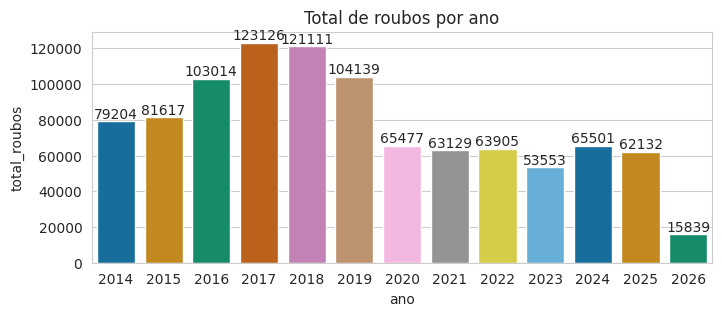

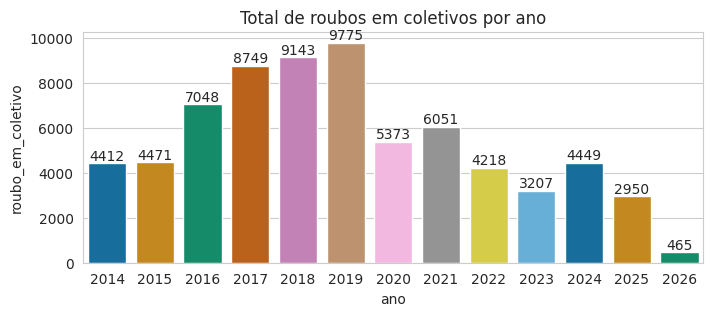

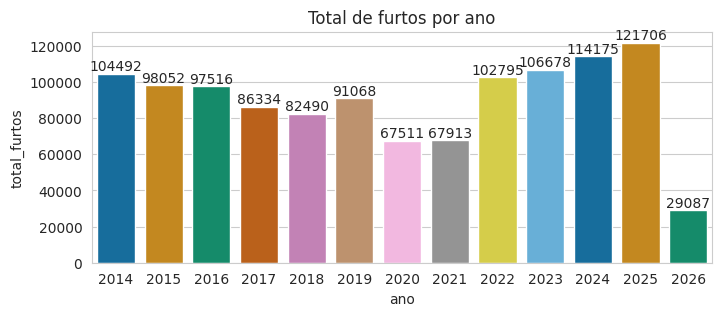

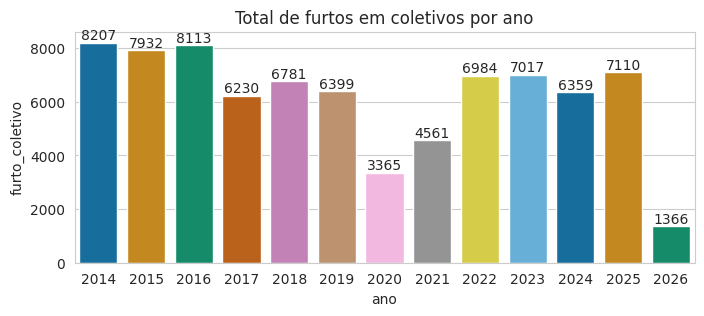

In [146]:
plt.figure(figsize=(8,3))
plt.title("Total de roubos por ano")
ax = sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.figure(figsize=(8,3))
plt.title("Total de roubos em coletivos por ano")
ax = sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.figure(figsize=(8,3))
plt.title("Total de furtos por ano")
ax = sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.figure(figsize=(8,3))
plt.title("Total de furtos em coletivos por ano")
ax = sns.barplot(data=df, x="ano", y="furto_coletivo", estimator="sum", palette=qualitativepalette, errorbar=None, hue="ano", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

Vemos que os furtos e roubos em coletivo são uma parte bem pequena dos furtos e roubos totais.

### Buscando correlações entre as colunas

Primeiramente, uma visão geral da correlação:

<Axes: >

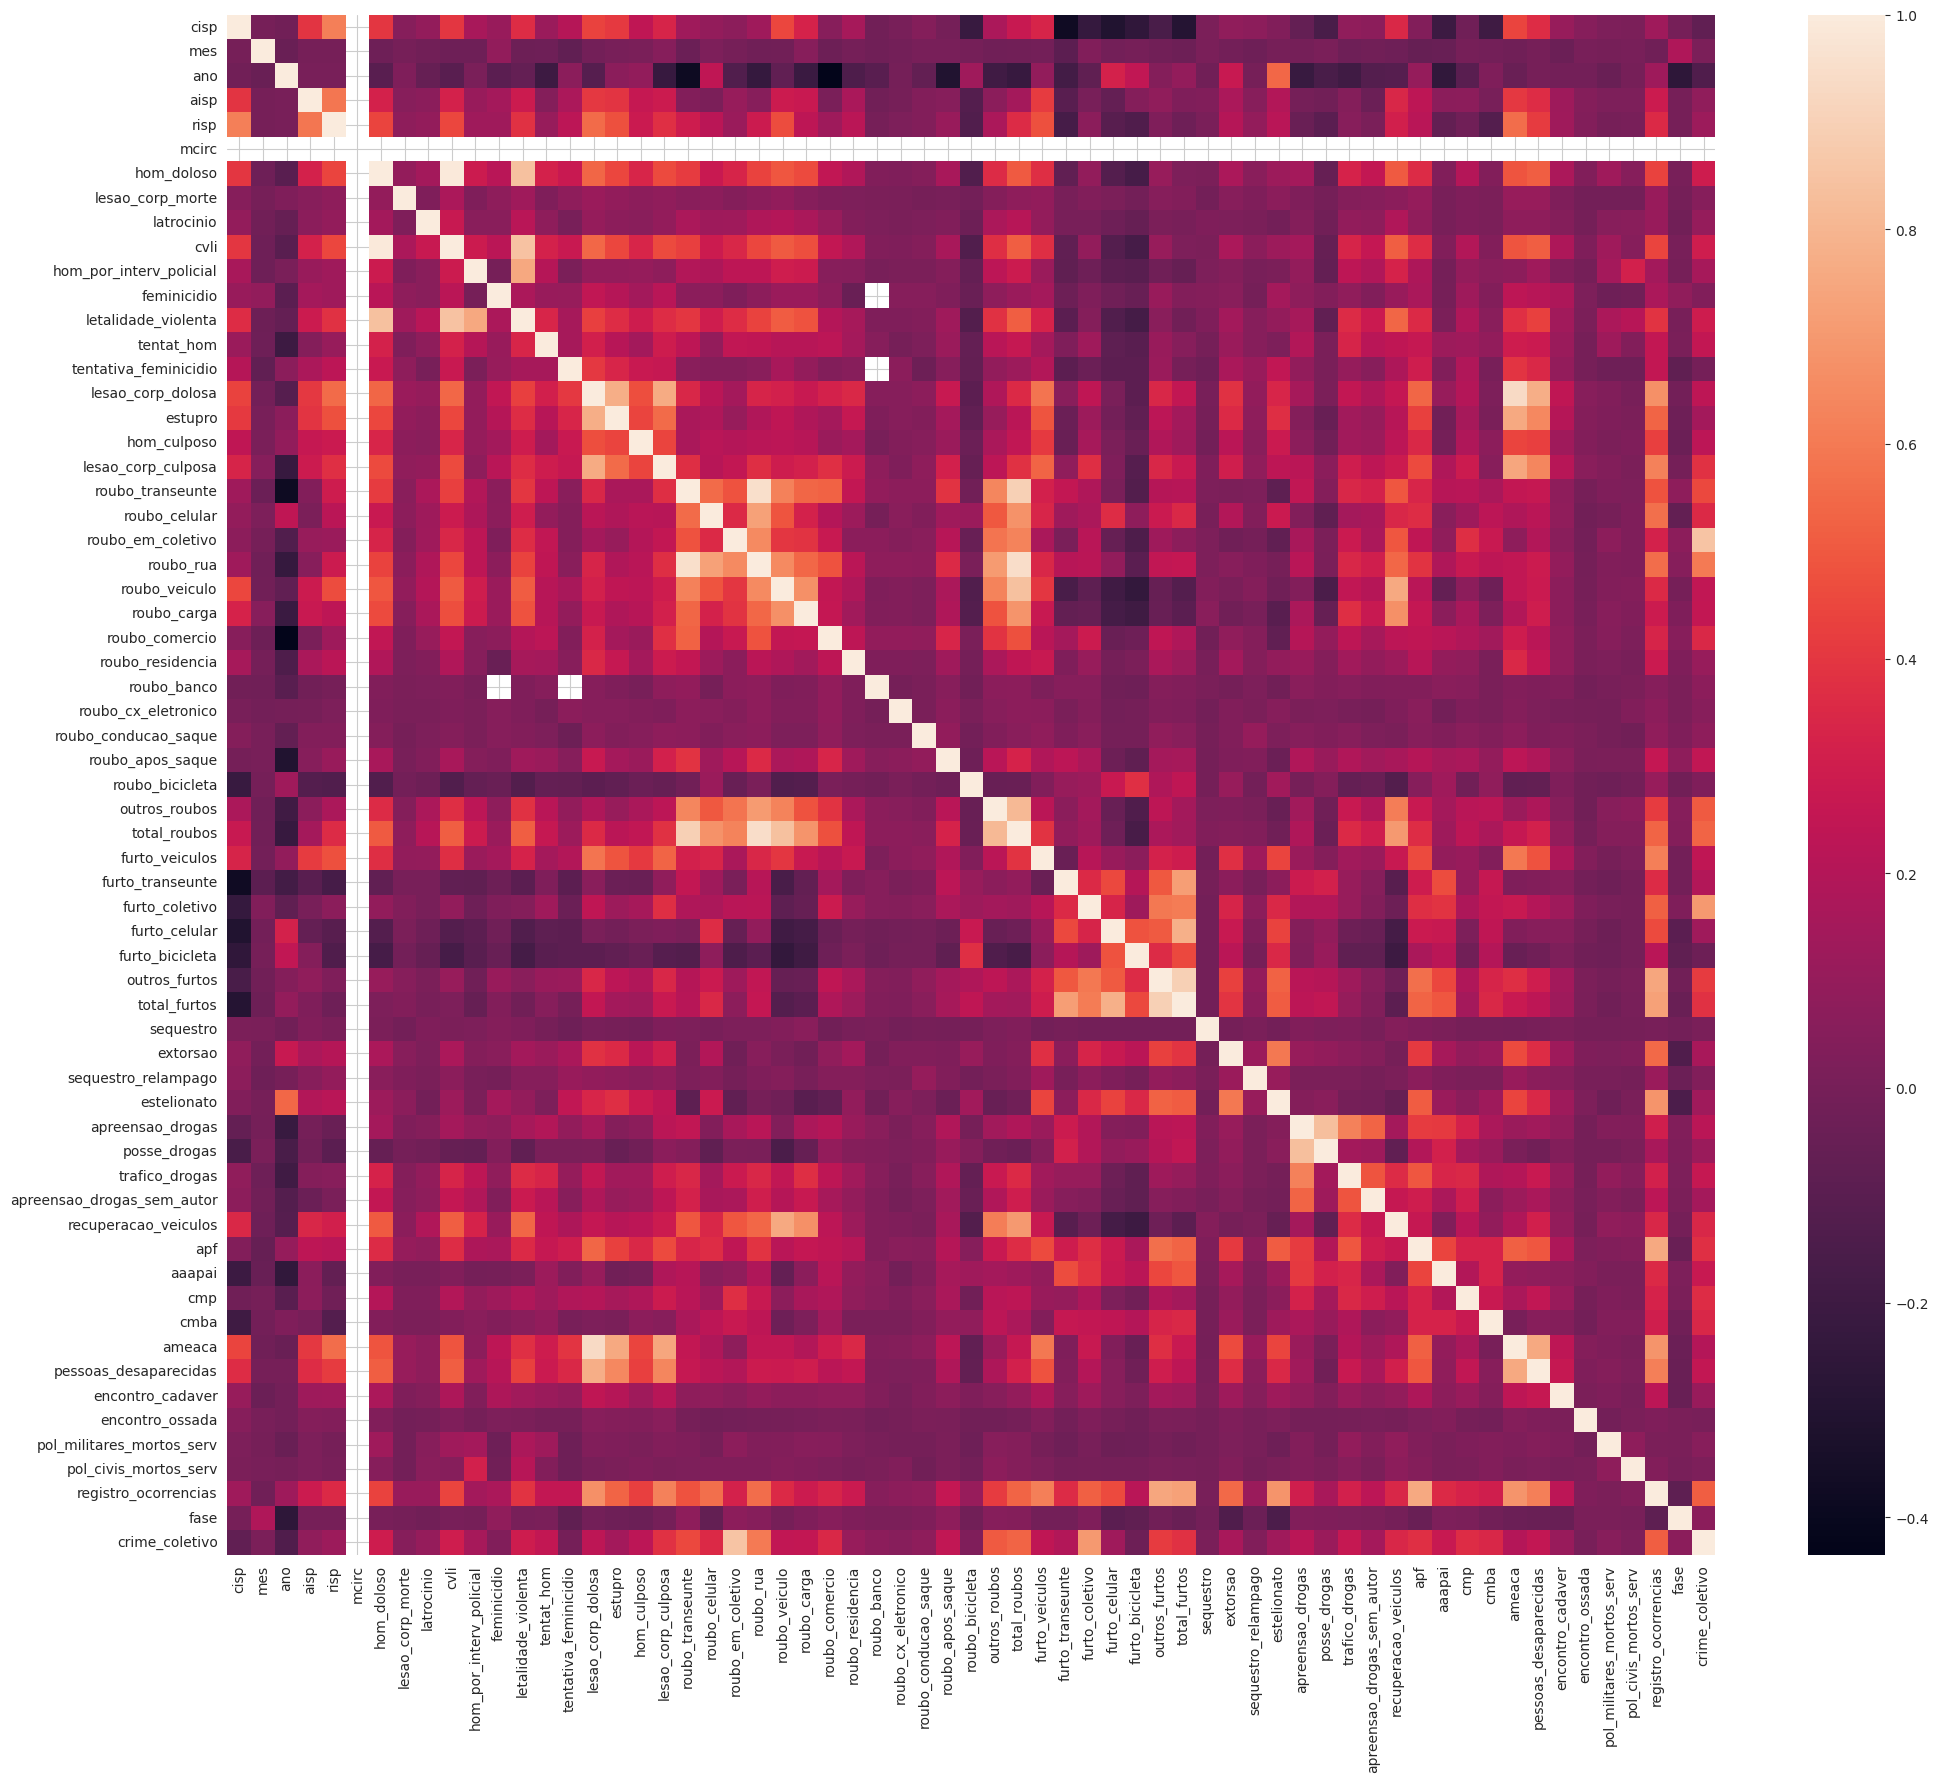

In [147]:
dfnumerical = df.select_dtypes(include=np.number)

plt.figure(figsize=(24,20))
sns.heatmap(dfnumerical.corr())

Como se tratam de muitas colunas, fica dificil tirar qualquer conclusão. Para selecionar mais delicadamente quais colunas visualizar no heatmap, determinamos arbitrariamente um `threshold` e visualizamos apenas os que tem correlação maior que esse valor.

Text(0.5, 1.0, 'Correlação com Roubo em Coletivo > 0.5')

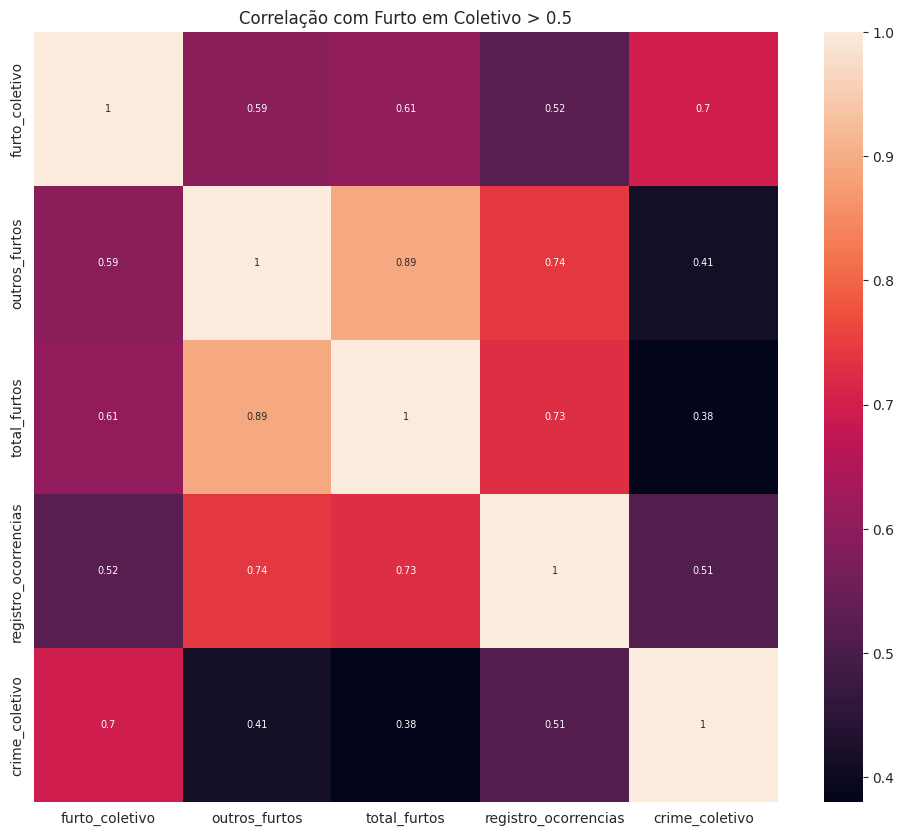

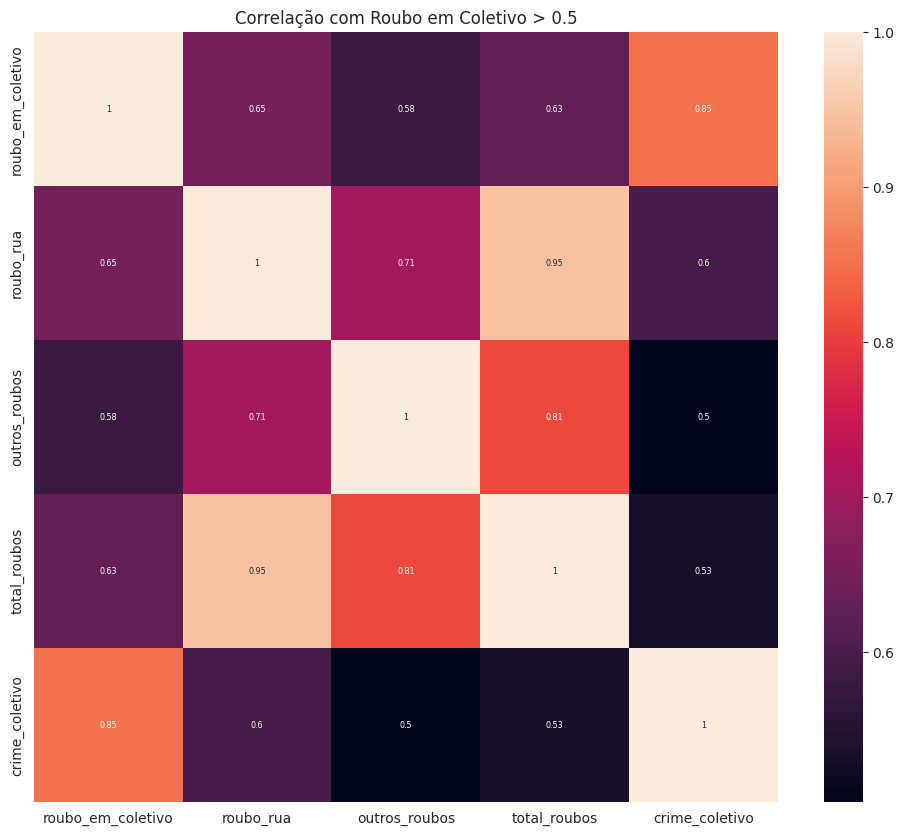

In [148]:
threshold = 0.5

dfheatmapcorrfurto = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["furto_coletivo"] > threshold]["furto_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrfurto, annot=True, annot_kws={"size": "x-small"}).set_title(f"Correlação com Furto em Coletivo > {threshold}")

dfheatmapcorrroubo = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["roubo_em_coletivo"] > threshold]["roubo_em_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrroubo, annot=True, annot_kws={"size": "xx-small"}).set_title(f"Correlação com Roubo em Coletivo > {threshold}")

Nesses heatmaps, vemos correlações apenas com crimes da mesma "estirpe": roubo com roubo, furto com furto, a maioria já esperado. O maior insight aqui é que roubos e furtos em coletivos tem baixa correlação entre si, como já prevemos. Essa ideia é reforçada pelo gráfico de disperção abaixo, que mostra a falta de padrões nas formas das RISPs

/tmp/ipykernel_21763/1688892770.py:1: UserWarning: The palette list has more values (20) than needed (2), which may not be intended.
  sns.scatterplot(data=df, x="furto_coletivo", y="roubo_em_coletivo", hue="risp", palette=qualitativepalette)


<Axes: xlabel='furto_coletivo', ylabel='roubo_em_coletivo'>

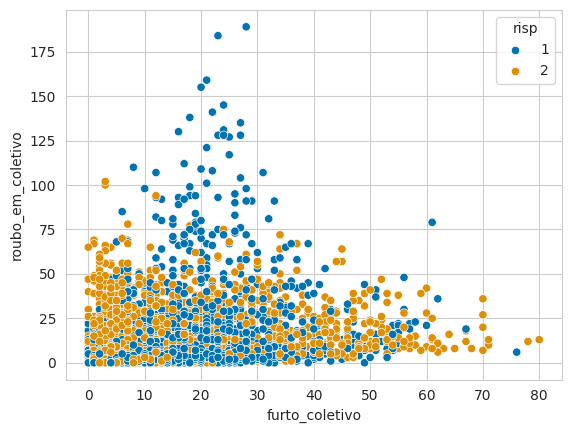

In [149]:
sns.scatterplot(data=df, x="furto_coletivo", y="roubo_em_coletivo", hue="risp", palette=qualitativepalette)

Para avaliar melhor, vamos plotar novamente o mapa de crimes, dessa vez separadamente:

In [150]:
df_map = df_coletivo.groupby("cisp")["furto_coletivo"].sum().reset_index()
faz_mapa("Furto contra Õnibus Total", "Número de crimes", df_map,["cisp","furto_coletivo"],"cisp")
IFrame(src="../Mapas/Furto contra Õnibus Total.html", width=700, height=400)

In [151]:
df_map = df_coletivo.groupby("cisp")["roubo_em_coletivo"].sum().reset_index()
faz_mapa("Roubo contra Õnibus Total", "Número de crimes", df_map,["cisp","roubo_em_coletivo"],"cisp")
IFrame(src="../Mapas/Roubo contra Õnibus Total.html", width=700, height=400)

A distinção entre as modalidades criminais torna-se evidente ao cruzar a natureza do delito com sua distribuição geográfica. Observa-se que os roubos em coletivos (caracterizados pelo uso de violência ou grave ameaça) apresentam maior prevalência em regiões da Zona Norte, Zona Oeste e Jacarepaguá. Em contrapartida, os furtos (subtração sem ameaça direta) concentram-se em áreas como a Zona Sul e Barra da Tijuca.
Essa segregação espacial explica a baixa correlação (0,1989) encontrada anteriormente: os crimes respondem a contextos socioeconômicos e oportunidades ambientais distintas. Enquanto o roubo pode estar vinculado a rotas de maior vulnerabilidade e ausência de policiamento ostensivo, o furto parece seguir a lógica da oportunidade em locais de alta densidade de bens de valor e fluxo de transeuntes. Essa heterogeneidade justifica a decisão de modelar cada variável de forma independente, utilizando tratamentos específicos para cada localidade.

### Roubos e furtos em coletivos através do tempo

Vamos valiar a evolução dos roubos e furtos totais ao longo dos anos. Iremos caracterizar por RISPs, que são um nível menos granular que as CISPs, para facilitar a visualização inicialmente.

Primeiro, vamos ver um histograma mostrando a quantidade total de roubos e furtos em todos os anos por RISP.

/tmp/ipykernel_21763/460210649.py:2: UserWarning: The palette list has more values (20) than needed (2), which may not be intended.
  sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
/tmp/ipykernel_21763/460210649.py:4: UserWarning: The palette list has more values (20) than needed (2), which may not be intended.
  sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


<Axes: xlabel='ano', ylabel='furto_coletivo'>

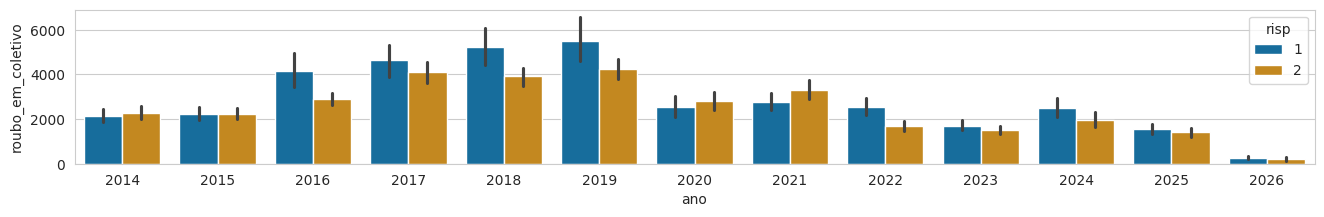

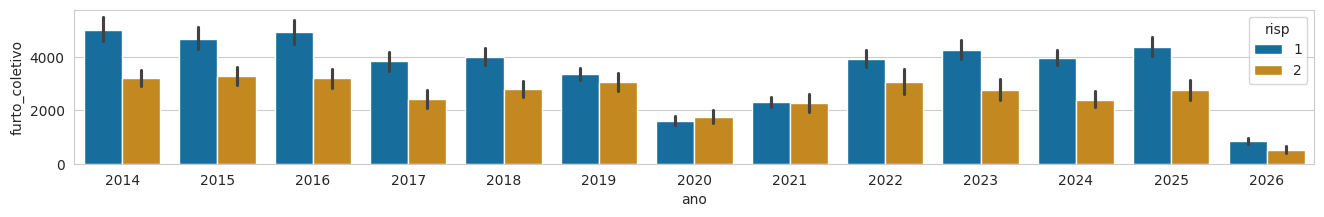

In [152]:
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)

Observa-se, através da categorização por RISP, que o impacto da pandemia de COVID-19 gerou um comportamento atípico em todas as regiões, com quedas acentuadas nos registros. No entanto, a retomada apresenta distinções cruciais entre as modalidades: os furtos em coletivos recuperaram-se rapidamente, superando a tendência dos roubos, que permanecem em níveis de estabilidade inferiores aos picos de 2016. Essa evolução distinta reforça a independência estatística entre furtos e roubos. 
Tomou-se então, a decisão de realizar o recorte temporal a partir de 2021, fundamentada na mudança estrutural na dinâmica urbana do Rio de Janeiro. O cenário da mobilidade urbana e a dinâmica criminal sofreram alterações drásticas entre 2020 e 2021, tornando os dados pré-pandêmicos menos precisos para prever comportamentos atuais. A pandemia de COVID-19 alterou o fluxo de passageiros no transporte público. Dados anteriores a 2021 refletem um comportamento de deslocamento que não condiz com a realidade atual de regimes híbridos de trabalho e novas rotas comerciais. Ao focar no período pós-2021, garantimos que o modelo capture a "mancha criminal do novo normal". Modelos preditivos funcionam melhor quando treinados com dados que representam o comportamento atual do sistema. Como o objetivo é prever os próximos 5 anos e sugerir rotas seguras entre bairros, utilizar dados de 5 ou 10 anos atrás traria um viés de realidade que não existe mais nas ruas. 

In [153]:
df = df[df['ano'] >= 2021]

# Novo intervalo de tempo
print(f"Min: {df['mes_ano'].min()}, Max: {df['mes_ano'].max()}")

# Verificando as informações do DataFrame após o filtro
df.info()
print(df.shape)

Min: 2021m01, Max: 2026m03
<class 'pandas.DataFrame'>
Index: 2583 entries, 28957 to 37491
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        2583 non-null   int64  
 1   mes                         2583 non-null   int64  
 2   ano                         2583 non-null   int64  
 3   mes_ano                     2583 non-null   str    
 4   aisp                        2583 non-null   int64  
 5   risp                        2583 non-null   int64  
 6   munic                       2583 non-null   str    
 7   mcirc                       2583 non-null   int64  
 8   regiao                      2583 non-null   str    
 9   hom_doloso                  2583 non-null   int64  
 10  lesao_corp_morte            2583 non-null   int64  
 11  latrocinio                  2583 non-null   int64  
 12  cvli                        2583 non-null   int64  
 13  hom_por_interv_po

Em seguida, vamos ver um histograma mostrando a quantidade total de roubos e furtos por RISP.

/tmp/ipykernel_21763/4160195575.py:2: UserWarning: The palette list has more values (20) than needed (2), which may not be intended.
  sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
/tmp/ipykernel_21763/4160195575.py:4: UserWarning: The palette list has more values (20) than needed (2), which may not be intended.
  sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


<Axes: xlabel='ano', ylabel='furto_coletivo'>

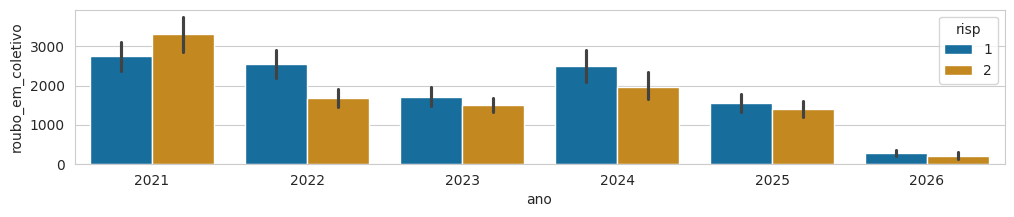

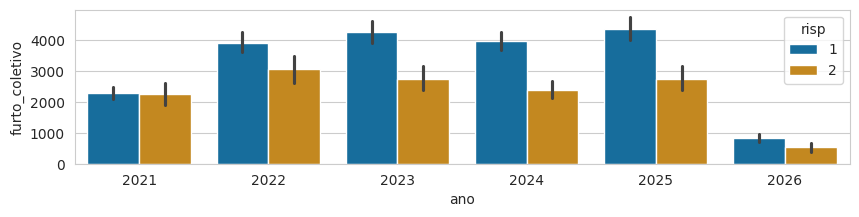

In [154]:
plt.figure(figsize=(12,2))
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
plt.figure(figsize=(10,2))
sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)

Enquanto a Zona Sul (RISP 1) brilha nos furtos devido à oportunidade e ao fluxo de turistas, enquanto a RISP 2 apresenta sempre uma menor quantidade de crimes no coletivo.

In [155]:
#Boxplot aqui

## Proporção entre Crimes no Coletivo e Total de Crimes
Vamos analisar agora a proporção entre os furtos e roubos cometidos no transporte público com o total desses crimes em todas as suas formas. Para essa análise, vamos separar por RISPs e analisar suas AISPs individualmente. Escolhemos a granularidade de AISP para essa análise pois elas compactam bairros com perfis parecidos de maneira mais compacta, facilitam a elaboração de insights.

### Proporção na RISP 1

In [156]:
df_RISP1 = df[df['risp'] == 1]

In [157]:
df_RISP1['proporcao_furto'] = (df_RISP1['furto_coletivo'] / df_RISP1['total_furtos']) 

df_total = df_RISP1.groupby('aisp')['proporcao_furto'].sum().reset_index()
df_total = df_total.sort_values(by='proporcao_furto', ascending=False)
print("AISP's com maior proporção de furtos em coletivo:")
print((df_total['aisp'].unique()))
tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Proporção de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

AISP's com maior proporção de furtos em coletivo:
[ 3  6  5  4 23 16 22  2 19 17]


aisp,proporcao_furto
3,23.127185
6,13.591889
5,12.946967
4,12.405760
23,10.680443
16,8.314264
22,6.987516
2,6.587890
19,3.565627
17,3.346372


In [158]:
df_RISP1['proporcao_roubo'] = (df_RISP1['roubo_em_coletivo'] / df_RISP1['total_roubos']) 

df_total = df_RISP1.groupby('aisp')['proporcao_roubo'].sum().reset_index()
df_total = df_total.sort_values(by='proporcao_roubo', ascending=False)
print("AISP's com maior proporção de roubos em coletivo:")
print((df_total['aisp'].unique()))
tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Proporção de Roubos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

AISP's com maior proporção de roubos em coletivo:
[ 4  5  3 23  6 22 16  2 19 17]


aisp,proporcao_roubo
4,20.255876
5,17.201157
3,16.490519
23,9.998201
6,9.074855
22,8.050938
16,7.014930
2,6.800886
19,3.675947
17,2.846938


Maior proporção de furtos em coletivo do total de furtos (23%) acontece na AISP 3 que corresponde à CISPs 23, 44, 25, 26, 24, áreas da Zona Norte do Rio de Janeiro, a região de atuação centraliza-se na Grande Méier, frequentemente associada a pontos como o Norte Shopping.

Para o segundo lugar, vemos um decaimento bem grande, na AISP 6, que corresponde a área da grande Tijuca, 13.5% dos furtos totais são no coletivo.

E em terceiro lugar, sendo 12% dos furtos em coletivos, as regiões do Centro do Rio e limites de São Cristóvão (AISP 5 e 4). 

Maior proporção de roubos em coletivo do total de roubos (20.3%) acontece na AISP 4 que corresponde à CISPs 6, 17, áreas entre São Cristóvão/Estácio.

Para o segundo lugar, na AISP 5, região próxima da AISP 4 com a maior proporção, que corresponde a área Central do Rio, 17% dos roubos totais são no coletivo.

E em terceiro lugar, sendo 16% dos roubos em coletivos, acontece na AISP 3 que corresponde à CISPs 23, 44, 25, 26, 24, áreas da Zona Norte do Rio de Janeiro, a região de atuação centraliza-se na Grande Méier, frequentemente associada a pontos como o Norte Shopping.

Concluímos que nas AISPs 3, 4 e 5, há um grande risco de violência, essas áreas abrangem do grande Méier até o Centro do Rio.

Maiores estatísticas:
A AISP 4 (São Cristóvão/Estácio) apresenta a maior concentração relativa de roubos em coletivo (20.3%), indicando um uso mais frequente de violência ou ameaça nessas conexões geográficas.
A AISP 3 (Grande Méier) é o centro dos furtos em coletivo (23%), sugerindo que locais de grande aglomeração e fluxo comercial, como o entorno do Norte Shopping ou engenhão favorecem ações de oportunidade sem o uso de força direta.

Enquanto o Centro ocupa o segundo lugar na proporção de roubos em coletivo (17%), ele ocupa o terceiro lugar (12%) em furtos, mostrando uma diferença no perfil criminal.
Isso pode indicar que na região Central do Rio, as abordagens costumam ser mais violentas em comparação à Grande Tijuca que têm maior predominância de furtos (13.5%)

### Proporção na RISP 2

In [159]:
df_RISP2 = df[df['risp'] == 2]

In [160]:
df_RISP2['proporcao_furto'] = (df_RISP2['furto_coletivo'] / df_RISP2['total_furtos'])

df_total = df_RISP2.groupby('aisp')['proporcao_furto'].sum().reset_index()
df_total = df_total.sort_values(by='proporcao_furto', ascending=False)
print("AISP's com maior proporção de furtos em coletivo:")
print((df_total['aisp'].unique()))  
tabela_furto = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Proporção de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_furto

AISP's com maior proporção de furtos em coletivo:
[18  9 41 31 14 27 40]


aisp,proporcao_furto
18,21.958025
9,12.956570
41,10.125161
31,8.767720
14,6.309584
27,5.881268
40,2.488953


In [161]:
df_RISP2['proporcao_roubo'] = (df_RISP2['roubo_em_coletivo'] / df_RISP2['total_roubos']) 

df_total = df_RISP2.groupby('aisp')['proporcao_roubo'].sum().reset_index()
df_total = df_total.sort_values(by='proporcao_roubo', ascending=False)
print("AISP's com maior proporção de roubos em coletivo:")
print((df_total['aisp'].unique()))
tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Proporção de Roubos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

AISP's com maior proporção de roubos em coletivo:
[41  9 27 31 18 14 40]


aisp,proporcao_roubo
41,14.114597
9,10.890654
27,8.976543
31,8.799152
18,6.976929
14,5.720266
40,2.826387


AISP 18, abrange a região de Jacarepaguá e adjacências, na Zona Oeste tem 22% dos furtos em coletivo em relação ao total.
AISP 9, na região de Rocha Miranda e Honório Gurgel, mais bairros próximos, na Zona Norte, tem 13% dos furtos sendo em coletivo.
AISP 41, sediada na Pavuna, Irajá, Anchieta, zona Norte/Subúrbio no Rio, tem 10%  dos furtos sendo em coletivo.
AISP 31, correspondente a área da Barra da Tijuca e adjacentes, tem 8.7% dos furtos sendo em coletivo.

AISP 41, sediada na Pavuna, Irajá, Anchieta, zona Norte/Subúrbio no Rio, tem 14% dos roubos totais sendo no coletivo.
AISP 9, na região de Rocha Miranda e Honório Gurgel, mais bairros próximos, na Zona Norte, tem 11% dos roubos totais sendo no coletivo.
AISPs 27 (Santa Cruz e bairros próximos) e 31 (Barra da Tijuca e adjacentes) tem 9% dos roubos totais sendo no coletivo.

A **AISP 18** (Jacarepaguá, Anil, Cidade de Deus, Curicica, Gardênia Azul e Taquara) apresenta um índice alarmante: **22% dos furtos** da região ocorrem dentro de coletivos.
Este valor é quase equivalente ao da **AISP 3** (Grande Méier), consolidando Jacarepaguá como um dos principais eixos de furtos por oportunidade no Rio de Janeiro. # ver Brts e onibus conectando meier e freguesia
As **CISPs 32, 28 e 41** (AISP 18) são pontos críticos onde a aglomeração em linhas de ônibus locais e alimentadoras do BRT pode estar facilitando essa modalidade.

A **AISP 41** (Pavuna, Irajá, Anchieta, Ricardo de Albuquerque e arredores) demonstra alto risco: embora responda por 10% dos furtos em coletivo, ela sobe para **14% no índice de roubos**.
Isso indica que, nesta região (atendida pelas **CISPs 31, 27 e 39**), a abordagem em ônibus é mais frequentemente realizada com uso de violência ou ameaça.
A proximidade com grandes vias de escoamento e acessos a comunidades pode influenciar a logística de fuga após os roubos nos coletivos.

A **AISP 31** (Barra da Tijuca, Recreio, Itanhangá e Joá) mantém índices relativamente equilibrados: **8.7% de furtos** e **9% de roubos** em coletivos.
Já a **AISP 27** (Santa Cruz, Guaratiba e Sepetiba), embora mais afastada, iguala-se à Barra da Tijuca nos roubos (9%), indicando que a malha de transporte na região também possui pontos de vulnerabilidade à violência.

A **AISP 9** (Rocha Miranda, Honório Gurgel, Madureira e adjacências) apresenta uma distribuição constante entre furto (13%) e roubo (11%).
Essa região, que engloba as **CISPs 29, 30 e 40**, funciona como um importante nó de integração de transporte na Zona Norte, servindo de base para ambas as modalidades criminosas.

**Resumo das Zonas:**
*   **Zona Norte (AISPs 3, 4, 9, 41):** Concentra o maior volume de roubos e furtos combinados, com destaque para a Pavuna nos crimes violentos. # Ver onde tem mais outros tipos de crimes
*   **Zona Oeste (AISPs 18, 31, 27):** Apresenta Jacarepaguá como o maior polo de furtos da região, enquanto a Barra da Tijuca e Santa Cruz mantêm níveis moderados de roubo em comparação ao subúrbio.
*   **Centro (AISP 5):** Continua sendo uma área de transição crítica com alta incidência de roubos (17%).

### Geral
Para ter uma visão mais ampla, podemos considerar os crimes independente de locação.

<Axes: xlabel='ano', ylabel='total_furtos'>

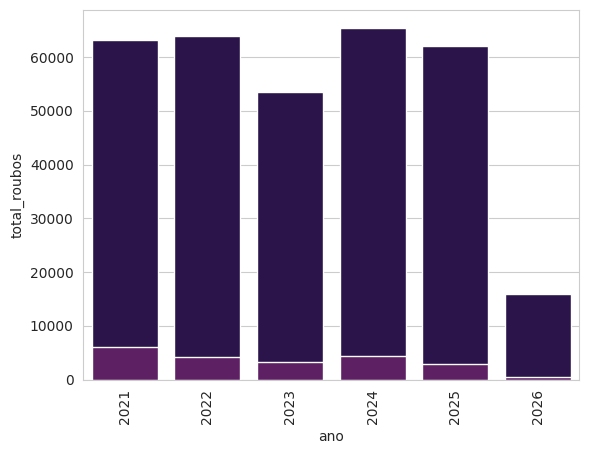

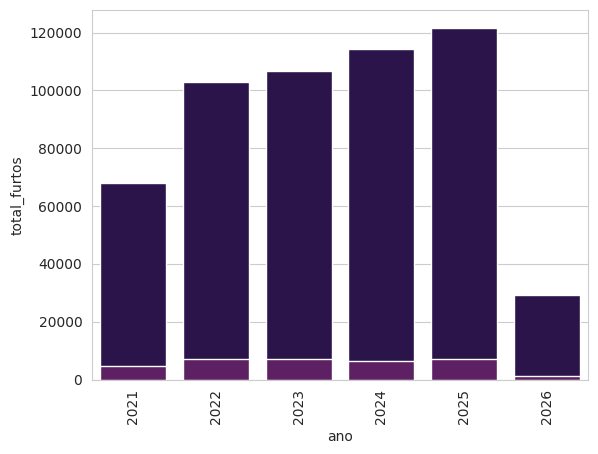

In [162]:
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum", errorbar=None, color=sequentialpalette[0])
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum", errorbar=None, color=sequentialpalette[1])
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum", errorbar=None, color=sequentialpalette[0])
sns.barplot(data=df, x="ano", y="furto_coletivo", estimator="sum", errorbar=None, color=sequentialpalette[1])

Podemos observar que os roubos e furtos nos coletivos são uma proporção relativamente baixa nas suas contrapartes gerais, indicando que esses crimes ocorrem geralmente em outros ambientes. No entando, pode ser mais fácil evitar sofrer crimes nos coletivos do que em outros ambientes dada a natureza móvel dos ambientes de ocorrência. Por exemplo, escolher rotas de ônibus que evitam áreas perigosas é uma forma de, em um nível individual, evitar ser vítima desses perigos.

## Maiores Incidências de Roubos e Furtos no Coletivo
Pensando em evitar essas áreas perigosas, podemos começar a nos perguntar quais são elas. Vamos ver um pouco sobre isso.

CISP's com maior número de furtos:
[16 32 21 29 10  4  6 19 17  1 18 20 25 42 35]


/tmp/ipykernel_21763/4121151056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


cisp,furto_coletivo
16,2998
32,2317
21,1947
29,1656
10,1511
4,1235
6,1211
19,1165
17,1139
1,1053


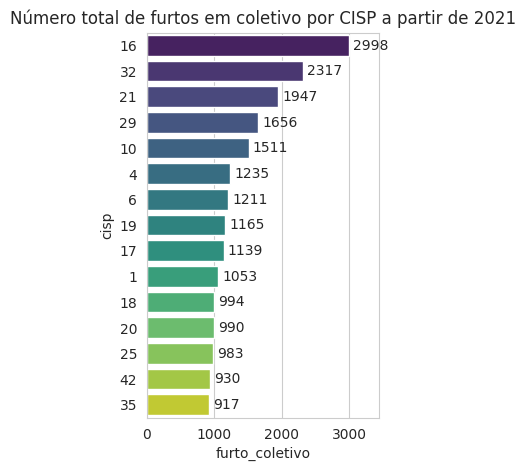

In [163]:
df_total = df.groupby('cisp')['furto_coletivo'].sum().reset_index()
df_total = df_total.sort_values(by='furto_coletivo', ascending=False).head(15)

print("CISP's com maior número de furtos:")
print((df_total['cisp'].unique()))

plt.figure(figsize=(3, 5)) 
ax = sns.barplot(
    data=df_total, 
    x="furto_coletivo",     
    y=df_total["cisp"].astype(str), 
    palette="viridis"       
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fmt='%d')
plt.xlim(0, df_total['furto_coletivo'].max() * 1.15)
plt.title("Número total de furtos em coletivo por CISP a partir de 2021")

tabela_furto = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Total de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_furto

CISP's com maior número de roubos:
[21 39 17 29 32 34 25 18  6 16  4 27 40 22 31]


/tmp/ipykernel_21763/1890047780.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


cisp,roubo_em_coletivo
21,2117
39,1932
17,1403
29,1198
32,917
34,851
25,849
18,804
6,769
16,753


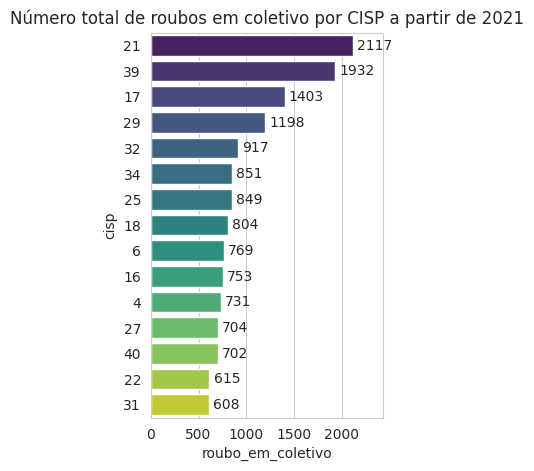

In [164]:
df_total = df.groupby('cisp')['roubo_em_coletivo'].sum().reset_index()
df_total = df_total.sort_values(by='roubo_em_coletivo', ascending=False).head(15)

print("CISP's com maior número de roubos:")
print((df_total['cisp'].unique()))

plt.figure(figsize=(3, 5)) 
ax = sns.barplot(
    data=df_total, 
    x="roubo_em_coletivo",     
    y=df_total["cisp"].astype(str), 
    palette="viridis"       
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fmt='%d')
plt.xlim(0, df_total['roubo_em_coletivo'].max() * 1.15)
plt.title("Número total de roubos em coletivo por CISP a partir de 2021")

tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Total de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

CISP's com maior número de furtos:
[16 32 21 29 10  4  6 19 17  1 18 20 25 42 35]

CISP's com maior número de roubos:
[64 21 39 59 17 29 54 32 34 25 18 53 60  6 16]

CISP's que aparecem em ambas listas: 
6 Catumbi, Cidade Nova, Estácio, Rio Comprido e Centro (parte)
16 Barra da Tijuca, Itanhangá, Joá
17 Caju, Mangueira, São Cristóvão e Vasco da Gama
18 Maracanã, Praça da Bandeira e Tijuca (parte)
21 Benfica, Bonsucesso, Higienópolis, Manguinhos, Maré e Ramos
25 Engenho Novo, Jacaré, Jacarezinho, Riachuelo, Rocha, Sampaio e
São Francisco Xavier
29 Cavalcanti, Engenheiro Leal, Madureira, Turiaçu, Vaz Lobo,
Oswaldo Cruz (parte), Cascadura e Quintino Bocaiúva
32 Anil, Cidade de Deus, Curicica, Gardênia Azul, Jacarepaguá e
Taquara 


Com essa ideia em mente, o objetivo é tentar criar uma forma de evitar essas CISPs mais perigosas de forma a reduzir a quantidade de vítimas de furto e roubo no transporte público da cidade

In [165]:
# Pensei em daí começar aqui a parte de EDA_temporal_cisps